Загрузка библиотек:

In [1]:
import learn
import torch
import torch.optim as optim
from torch import nn
from torchvision import datasets, transforms

Загрузка данных:

In [14]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0, std=1)
])

train_set = datasets.MNIST(
    'c:/Datasets/',
    download=True,
    train=True,
    transform=transform_mnist
)

Преобразование меток:

In [15]:
def convert_label(label):

    mapping = {
        0:0, 6:0,
        1:1, 7:1,
        2:2, 3:2,
        4:3, 9:3,
        5:4, 8:4
    }

    return mapping[label]

In [16]:
class MyMNIST(torch.utils.data.Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        img, label = self.dataset[idx]

        label = convert_label(label)

        return img, label

In [17]:
train_set = MyMNIST(train_set)

for i in range(10):
    img, label = train_set[i]
    print(i, label)

0 4
1 0
2 3
3 1
4 3
5 2
6 1
7 2
8 1
9 3


Настройки модели и процесса обучения:

In [18]:
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=64,
    shuffle=True
)

In [19]:
class SimpleNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(784, 5)
        self.act = nn.Softmax(dim=1)

    def forward(self, x):

        x = self.fc(x)
        x = self.act(x)

        return x

In [20]:
model = SimpleNN()

In [21]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.003
)

loss_fn = nn.MSELoss()

Тестовый набор:

In [22]:
test_set = datasets.MNIST(
    'c:/Datasets/',
    download=False,
    train=False,
    transform=transform_mnist
)

test_set = MyMNIST(test_set)

In [23]:
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=64,
    shuffle=False
)

Обучение:

In [24]:
train_losses = []
test_losses = []

n_epochs = 50

for epoch in range(n_epochs):

    # Обучение
    model.train()

    total_train_loss = 0

    for X, y_true in train_loader:

        X = X.view(X.shape[0], -1)

        y_pred = model(X)

        y_onehot = torch.nn.functional.one_hot(
            y_true,
            num_classes=5
        ).float()

        loss = loss_fn(y_pred, y_onehot)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss)

    # Тестирование
    model.eval()

    total_test_loss = 0

    with torch.no_grad():

        for X, y_true in test_loader:

            X = X.view(X.shape[0], -1)

            y_pred = model(X)

            y_onehot = torch.nn.functional.one_hot(
                y_true,
                num_classes=5
            ).float()

            loss = loss_fn(y_pred, y_onehot)

            total_test_loss += loss.item()

    test_losses.append(total_test_loss)

    print(
        f'Epoch {epoch+1}: '
        f'train_loss={total_train_loss:.4f}, '
        f'test_loss={total_test_loss:.4f}'
    )

Epoch 1: train_loss=138.7716, test_loss=21.3581
Epoch 2: train_loss=120.0353, test_loss=18.3377
Epoch 3: train_loss=104.7176, test_loss=15.9816
Epoch 4: train_loss=92.9029, test_loss=14.1963
Epoch 5: train_loss=83.9196, test_loss=12.8486
Epoch 6: train_loss=77.0575, test_loss=11.8204
Epoch 7: train_loss=71.7229, test_loss=11.0209
Epoch 8: train_loss=67.4922, test_loss=10.3866
Epoch 9: train_loss=64.0722, test_loss=9.8724
Epoch 10: train_loss=61.2554, test_loss=9.4440
Epoch 11: train_loss=58.8828, test_loss=9.0857
Epoch 12: train_loss=56.8647, test_loss=8.7778
Epoch 13: train_loss=55.1332, test_loss=8.5136
Epoch 14: train_loss=53.5909, test_loss=8.2819
Epoch 15: train_loss=52.2500, test_loss=8.0774
Epoch 16: train_loss=51.0490, test_loss=7.8943
Epoch 17: train_loss=49.9703, test_loss=7.7302
Epoch 18: train_loss=48.9880, test_loss=7.5827
Epoch 19: train_loss=48.1056, test_loss=7.4470
Epoch 20: train_loss=47.3011, test_loss=7.3243
Epoch 21: train_loss=46.5570, test_loss=7.2094
Epoch 22: t

Изменение ошибки:

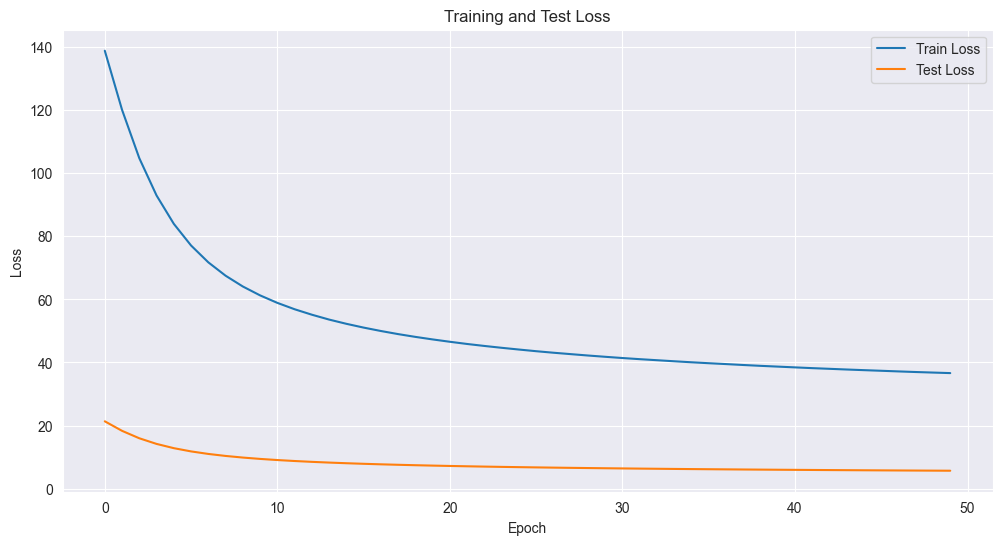

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')

plt.legend()
plt.grid(True)

plt.show()

Предсказания на тестовой выборке:

In [26]:
from sklearn.metrics import confusion_matrix

all_true = []
all_pred = []

model.eval()

with torch.no_grad():

    for X, y_true in test_loader:

        X = X.view(X.shape[0], -1)

        outputs = model(X)

        _, y_pred = torch.max(outputs, dim=1)

        all_true += list(y_true.numpy())
        all_pred += list(y_pred.numpy())

Точность:

In [27]:
correct = sum(t == p for t, p in zip(all_true, all_pred))
accuracy = correct / len(all_true)

print(f'Accuracy = {accuracy:.4f}')

Accuracy = 0.8982


Матрица спутывания:

In [28]:
cm = confusion_matrix(all_true, all_pred)

print(cm)

[[1814   10   29   34   51]
 [   7 1973   60   79   44]
 [  53   69 1768   36  116]
 [  48   44   19 1842   38]
 [  65   56  114   46 1585]]


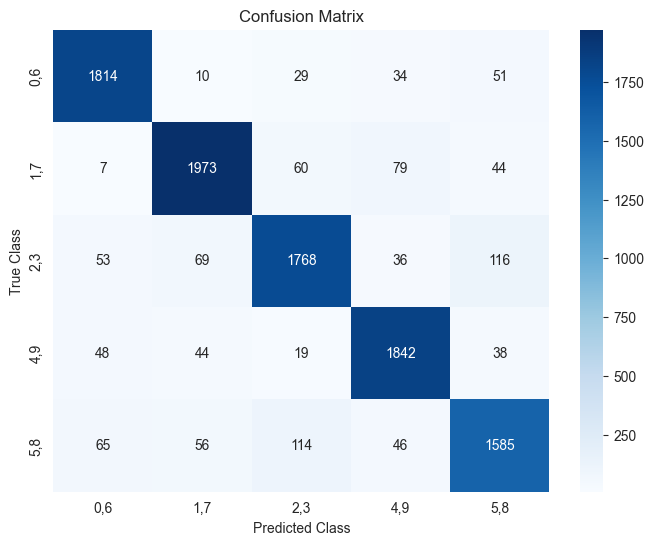

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = [
    '0,6',
    '1,7',
    '2,3',
    '4,9',
    '5,8'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')

plt.show()

Модель с двумя слоями:

In [30]:
class TwoLayerNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 5)
        self.act = nn.Softmax(dim=1)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.act(x)

        return x

Создание модели:

In [31]:
model2 = TwoLayerNN()

optimizer2 = optim.SGD(model2.parameters(), lr=0.003)

loss_fn2 = nn.MSELoss()

Обучение:

In [32]:
train_losses2 = []
test_losses2 = []

n_epochs = 50

for epoch in range(n_epochs):

    # Обучающая
    model2.train()
    total_train_loss = 0

    for X, y_true in train_loader:

        X = X.view(X.shape[0], -1)

        y_pred = model2(X)

        y_onehot = torch.nn.functional.one_hot(
            y_true,
            num_classes=5
        ).float()

        loss = loss_fn2(y_pred, y_onehot)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        total_train_loss += loss.item()

    train_losses2.append(total_train_loss)

    # Тестовая
    model2.eval()
    total_test_loss = 0

    with torch.no_grad():

        for X, y_true in test_loader:

            X = X.view(X.shape[0], -1)

            y_pred = model2(X)

            y_onehot = torch.nn.functional.one_hot(
                y_true,
                num_classes=5
            ).float()

            loss = loss_fn2(y_pred, y_onehot)

            total_test_loss += loss.item()

    test_losses2.append(total_test_loss)

    print(f'Epoch {epoch+1}: train={total_train_loss:.4f}, test={total_test_loss:.4f}')

Epoch 1: train=148.8724, test=24.6466
Epoch 2: train=145.7036, test=24.0487
Epoch 3: train=141.9776, test=23.3259
Epoch 4: train=137.4051, test=22.4313
Epoch 5: train=131.7403, test=21.3275
Epoch 6: train=124.8742, test=20.0186
Epoch 7: train=116.9835, test=18.5610
Epoch 8: train=108.4762, test=17.0395
Epoch 9: train=99.8200, test=15.5425
Epoch 10: train=91.4621, test=14.1362
Epoch 11: train=83.7563, test=12.8735
Epoch 12: train=76.9165, test=11.7777
Epoch 13: train=71.0302, test=10.8531
Epoch 14: train=66.0659, test=10.0855
Epoch 15: train=61.9111, test=9.4466
Epoch 16: train=58.4282, test=8.9139
Epoch 17: train=55.4808, test=8.4676
Epoch 18: train=52.9802, test=8.0874
Epoch 19: train=50.8457, test=7.7646
Epoch 20: train=48.9737, test=7.4845
Epoch 21: train=47.3418, test=7.2380
Epoch 22: train=45.8922, test=7.0223
Epoch 23: train=44.6096, test=6.8301
Epoch 24: train=43.4734, test=6.6599
Epoch 25: train=42.4261, test=6.5053
Epoch 26: train=41.4848, test=6.3663
Epoch 27: train=40.6386, 

График ошибки:

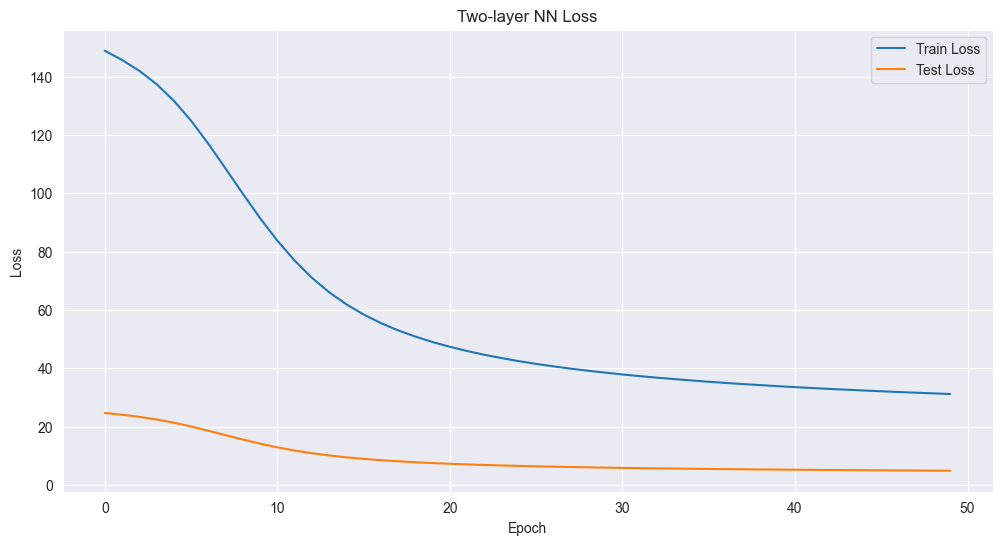

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses2, label='Train Loss')
plt.plot(test_losses2, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Two-layer NN Loss')

plt.legend()
plt.grid(True)

plt.show()

Предсказания на тестовой выборке:

In [34]:
all_true2 = []
all_pred2 = []

model2.eval()

with torch.no_grad():

    for X, y_true in test_loader:

        X = X.view(X.shape[0], -1)

        outputs = model2(X)

        _, y_pred = torch.max(outputs, dim=1)

        all_true2.extend(y_true.cpu().numpy())
        all_pred2.extend(y_pred.cpu().numpy())

Точность:

In [35]:
correct2 = sum(t == p for t, p in zip(all_true2, all_pred2))
accuracy2 = correct2 / len(all_true2)

print(f'Accuracy = {accuracy2:.4f}')

Accuracy = 0.9085


Матрица спутывания:

In [36]:
cm2 = confusion_matrix(all_true2, all_pred2)

print(cm2)

[[1834    8   24   34   38]
 [   8 1992   55   71   37]
 [  46   60 1799   33  104]
 [  43   43   17 1851   37]
 [  59   52  111   35 1609]]


Визуализация матрицы:

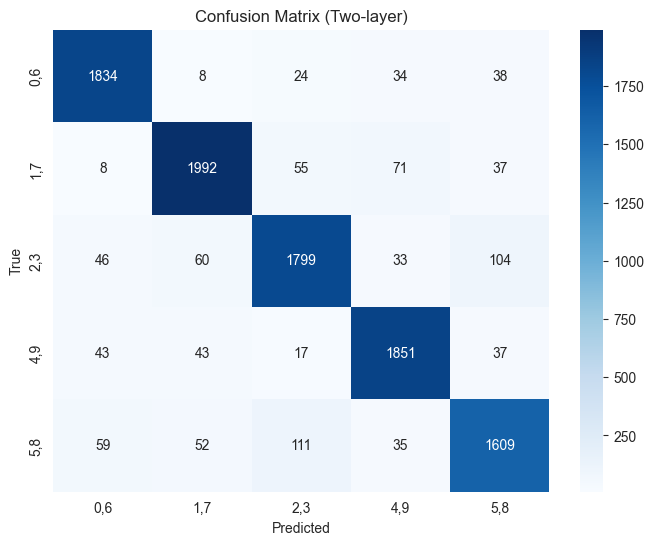

In [37]:
import seaborn as sns

labels = ['0,6','1,7','2,3','4,9','5,8']

plt.figure(figsize=(8,6))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Two-layer)')

plt.show()